In [2]:
from ai2thor.controller import Controller

In [3]:
import numpy as np

In [4]:
controller = Controller(
    width=1280,
    height=720,
    quality="Ultra"
)

In [5]:
controller.step("RotateLeft", degrees=45)

<ai2thor.server.Event at 0x7af944f1b790
    .metadata["lastAction"] = RotateLeft
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [6]:
event = controller.step(
    action="AddThirdPartyCamera",
    position=dict(x=-1.25, y=1, z=-1),
    rotation=dict(x=90, y=0, z=0),
    fieldOfView=90
)

event.third_party_camera_frames

[array([[[182, 171, 150],
         [182, 171, 150],
         [182, 171, 150],
         ...,
         [220, 199, 180],
         [220, 200, 180],
         [220, 200, 181]],
 
        [[186, 174, 153],
         [186, 174, 153],
         [186, 174, 153],
         ...,
         [222, 201, 182],
         [222, 201, 182],
         [222, 202, 183]],
 
        [[188, 177, 155],
         [188, 177, 155],
         [188, 177, 155],
         ...,
         [223, 204, 184],
         [224, 204, 184],
         [224, 204, 185]],
 
        ...,
 
        [[202, 192, 170],
         [201, 192, 170],
         [201, 192, 170],
         ...,
         [156, 147, 131],
         [154, 145, 129],
         [152, 143, 127]],
 
        [[200, 191, 169],
         [200, 191, 169],
         [200, 191, 169],
         ...,
         [155, 147, 130],
         [153, 144, 128],
         [152, 143, 127]],
 
        [[199, 190, 168],
         [199, 190, 167],
         [199, 190, 167],
         ...,
         [154, 145, 130],
  

In [7]:
controller.reset()

<ai2thor.server.Event at 0x7af9450b57d0
    .metadata["lastAction"] = Initialize
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = {'cameraNearPlane': 0.009999999776482582, 'cameraFarPlane': 20.0}
>

(-0.5, 1279.5, 719.5, -0.5)

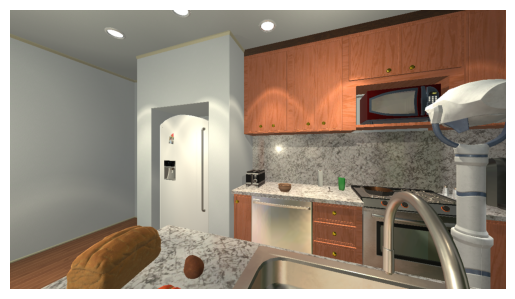

In [32]:
import matplotlib.pyplot as plt
event = controller.step(
    action="AddThirdPartyCamera",
    position=dict(x=-1.2, y=1.4, z=-0.5),
    rotation=dict(x=0, y=70, z=0),
    fieldOfView=80
)
plt.imshow(event.third_party_camera_frames[-1])
plt.axis('off')

In [8]:
import os
from PIL import Image
import numpy as np

output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

print("Saving to:", output_dir)

# Create camera once
controller.step(
    action="AddThirdPartyCamera",
    position=dict(x=-1.2, y=1.4, z=-0.5),
    rotation=dict(x=0, y=0, z=0),
    fieldOfView=80
)

for y_rot in range(0, 360, 1):

    event = controller.step(
        action="UpdateThirdPartyCamera",
        thirdPartyCameraId=0,
        position=dict(x=-1.2, y=1.4, z=-0.5),
        rotation=dict(x=0, y=y_rot, z=0),
        fieldOfView=80
    )

    img = event.third_party_camera_frames[0]

    # Convert to PIL image
    pil_img = Image.fromarray(np.uint8(img))

    filepath = os.path.join(output_dir, f"view_{y_rot:03d}.png")

    pil_img.save(filepath)

    print("Saved:", filepath)

Saving to: images
Saved: images/view_000.png
Saved: images/view_001.png
Saved: images/view_002.png
Saved: images/view_003.png
Saved: images/view_004.png
Saved: images/view_005.png
Saved: images/view_006.png
Saved: images/view_007.png
Saved: images/view_008.png
Saved: images/view_009.png
Saved: images/view_010.png
Saved: images/view_011.png
Saved: images/view_012.png
Saved: images/view_013.png
Saved: images/view_014.png
Saved: images/view_015.png
Saved: images/view_016.png
Saved: images/view_017.png
Saved: images/view_018.png
Saved: images/view_019.png
Saved: images/view_020.png
Saved: images/view_021.png
Saved: images/view_022.png
Saved: images/view_023.png
Saved: images/view_024.png
Saved: images/view_025.png
Saved: images/view_026.png
Saved: images/view_027.png
Saved: images/view_028.png
Saved: images/view_029.png
Saved: images/view_030.png
Saved: images/view_031.png
Saved: images/view_032.png
Saved: images/view_033.png
Saved: images/view_034.png
Saved: images/view_035.png
Saved: ima

In [31]:
event = controller.step('LookUp', degrees=15)

In [32]:
for i in range(2000):
    action = np.random.choice(['MoveAhead', 'MoveRight', 'MoveLeft', 'MoveBack', 'RotateRight', 'RotateLeft', 'LookUp', 'LookDown'])
    event = controller.step(action)

KeyboardInterrupt: 

In [ ]:
controller.__dict__

{'receptacle_nearest_pivot_points': {},
 'server': <ai2thor.fifo_server.FifoServer at 0x7daed25b9190>,
 'unity_pid': 14442,
 'container_id': None,
 'width': 512,
 'height': 512,
 'server_timeout': 100.0,
 'server_start_timeout': 300.0,
 'last_event': <ai2thor.server.Event at 0x7dae6fc26cd0
     .metadata["lastAction"] = LookUp
     .metadata["lastActionSuccess"] = True
     .metadata["errorMessage"] = "
     .metadata["actionReturn"] = None
 >,
 'scene': 'FloorPlan10_physics',
 '_scenes_in_build': {'ArchitecTHOR-Test-00',
  'ArchitecTHOR-Test-01',
  'ArchitecTHOR-Test-02',
  'ArchitecTHOR-Test-03',
  'ArchitecTHOR-Test-04',
  'ArchitecTHOR-Val-00',
  'ArchitecTHOR-Val-01',
  'ArchitecTHOR-Val-02',
  'ArchitecTHOR-Val-03',
  'ArchitecTHOR-Val-04',
  'FloorPlan10_physics',
  'FloorPlan11_physics',
  'FloorPlan12_physics',
  'FloorPlan13_physics',
  'FloorPlan14_physics',
  'FloorPlan15_physics',
  'FloorPlan16_physics',
  'FloorPlan17_physics',
  'FloorPlan18_physics',
  'FloorPlan19_phy